# Классификация: логистическая регрессия и метрики

## Содержание

0. Подготовка среды и подключение Weights & Biases
1. Данные: отток клиентов (Telco Customer Churn)
2. Логистическая регрессия
3. Метрики классификации
4. Порог: стоимость ошибок и пропускная способность
5. Практикум

Это занятие продолжает второе. Там вы обучали линейную регрессию и предсказывали число; теперь **та же линейная комбинация признаков** превращается в вероятность через сигмоиду, а целевая переменная становится классом. Пайплайн прежний (данные → EDA → модель → метрики → интерпретация), но метрики классификации совсем другие — им посвящена большая часть занятия.

Демонстрационный пример — задача прогноза **оттока клиентов** телеком-оператора (датасет Telco Customer Churn). Практикум (раздел 5) вы выполняете на **датасете своего проекта из занятия 2**. Запуски логируем в Weights & Biases (регистрация — из task 01). Выводы после каждого блока записывайте **в ячейке markdown прямо в блокноте**.

## 0. Подготовка среды и подключение Weights & Biases

К библиотекам первых двух занятий добавляется `wandb`. Датасет скачивается из интернета (небольшой файл), поэтому первый запуск займёт немного больше времени.

Для входа в W&B нужен API-ключ: https://wandb.ai/authorize (регистрация — из task 01). В Google Colab ключ удобно хранить в «Секретах» (значок ключа слева) и не вписывать в код.

W&B используется обязательно. Перед запуском выполните `wandb.login()` и авторизуйте аккаунт.

https://forge.coreweave.com/wandb/korovatomilk-no-company/apml-course

In [17]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)

import wandb

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
wandb.login()


True

## 1. Данные: отток клиентов (Telco Customer Churn)

Датасет описывает клиентов телеком-оператора: услуги, тарифы, срок обслуживания и факт ухода. Это классическая задача **бинарной классификации с учителем**.

**Постановка.** Объект — клиент. Момент предсказания — до начала кампании удержания. Действие после score — предложить скидку, позвонить, ничего не делать. Модель не заменяет решение: между вероятностью и действием стоят порог, стоимость ошибок и пропускная способность отдела удержания.

| Поле | Тип | Смысл |
|---|---|---|
| customerID | идентификатор | в признаки не входит |
| gender, Partner, Dependents | категориальный | демография |
| tenure | числовой | сколько месяцев с нами |
| PhoneService, MultipleLines | категориальный | телефония |
| InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport | категориальный | интернет-услуги |
| StreamingTV, StreamingMovies | категориальный | стриминг |
| Contract, PaperlessBilling, PaymentMethod | категориальный | договор и оплата |
| MonthlyCharges | числовой | месячный платёж |
| TotalCharges | числовой | суммарные платежи (в файле — текст с пустыми значениями) |
| Churn | целевая | Yes — клиент ушёл, No — остался |

Формально: объект $x \in \mathbb{R}^d$ (числовые признаки и one-hot категориальные), целевая переменная $y \in \{0, 1\}$; ищем $f(x) \to [0, 1]$ — вероятность оттока.

**Важная оговорка.** Доля оттока в датасете около 26% — это учебное распределение. В разрезе сегментов и периодов она отличается, а precision напрямую зависит от base rate: при меньшей доле уходящих precision при том же recall будет ниже.

In [2]:
DATA_URL = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
            "master/data/Telco-Customer-Churn.csv")
LOCAL_PATH = "telco_churn.csv"

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(LOCAL_PATH, index=False)

print("Размер таблицы:", df.shape)
print("Доля оттока:", round((df['Churn'] == 'Yes').mean(), 3))
df.head()


Размер таблицы: (7043, 21)
Доля оттока: 0.265


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Целевая переменная:")
print(df['Churn'].value_counts())
print("\nДубликаты строк:", df.duplicated().sum())

print("\nTotalCharges — тип:", df['TotalCharges'].dtype,
      "| некорректных значений:", int(pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()))

d = df.drop(columns=['customerID']).copy()
d['TotalCharges'] = pd.to_numeric(d['TotalCharges'], errors='coerce')
d['Churn'] = (d['Churn'] == 'Yes').astype(int)

num = [c for c in d.select_dtypes(include=np.number).columns if c != 'Churn']
cat = [c for c in d.columns if c not in num + ['Churn']]

print("\nЧисловых признаков:", len(num), "| категориальных:", len(cat))
print("Кардинальность категориальных:", {c: d[c].nunique() for c in cat})


Целевая переменная:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Дубликаты строк: 0

TotalCharges — тип: str | некорректных значений: 11

Числовых признаков: 4 | категориальных: 15
Кардинальность категориальных: {'gender': 2, 'Partner': 2, 'Dependents': 2, 'PhoneService': 2, 'MultipleLines': 3, 'InternetService': 3, 'OnlineSecurity': 3, 'OnlineBackup': 3, 'DeviceProtection': 3, 'TechSupport': 3, 'StreamingTV': 3, 'StreamingMovies': 3, 'Contract': 3, 'PaperlessBilling': 2, 'PaymentMethod': 4}


### Контроль утечек (leakage checklist)

- Удалить `customerID` — это идентификатор, а не признак.
- Исключить признаки, доступные только **после** целевого события (обращения в поддержку, причина расторжения, финальный счёт).
- Не обучать scaler/encoder/imputer до разбиения — весь препроцессинг держать внутри `Pipeline`.
- Осторожно с признаками, рассчитанными с использованием будущего (агрегаты за период после момента предсказания).
- Учитывать, что случайный split может быть оптимистичным, если у одного клиента в данных несколько строк.

**Задача 1.**
Проведите аудит датасета (пропуски, дубликаты, типы, кардинальность) и назовите минимум **четыре** потенциальных источника утечки именно для этой задачи, объяснив, чем каждый опасен. Ответ — в ячейке ниже.

In [4]:
print(df.info())
print("\nПропуски:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nДубликаты:", df.duplicated().sum())
print("\nТипы:")
print(df.dtypes)
print("\nКардинальность:")
print(df.nunique().sort_values())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Ваш ответ:**

В этой задаче возможны несколько источников утечки. `customerID` может дать модели возможность запомнить конкретных клиентов и их историю, поэтому его нужно исключить. `TotalCharges` опасен, если он содержит итоговые платежи, накопленные уже после момента прогноза: тогда модель видит информацию из будущего. Любые признаки, сформированные после решения об удержании или после факта ухода клиента, также нельзя использовать. Агрегаты за период, который пересекает момент предсказания, могут передавать будущую информацию. Наконец, повторные строки одного клиента в train и test создают утечку через идентичные или очень похожие наблюдения и завышают качество.


## 2. Логистическая регрессия

### Математический аппарат

Линейная комбинация признаков — та же, что и в занятии 2, но пропущенная через **сигмоиду**, чтобы результат лежал в $[0, 1]$ и трактовался как вероятность:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad P(y=1 \mid x) = \hat{y} = \sigma(w^\top x + b)$$

Эквивалентная запись через log-odds: $\log\frac{\hat{y}}{1-\hat{y}} = w^\top x + b$. После стандартизации знак коэффициента показывает направление связи, а $\exp(w_j)$ — во сколько раз меняются шансы оттока при росте признака на одно стандартное отклонение (при прочих равных).

Веса подбираются максимизацией правдоподобия, что даёт **binary cross-entropy**:

$$L(w) = -\frac{1}{n}\sum_{i=1}^{n}\left[\,y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\,\right] \to \min_{w}$$

*Смысл:* за уверенную ошибку ($\hat{y} \to 0$ при $y=1$) штраф растёт до бесконечности — модель наказывается именно за неверную уверенность, а не за сам неверный класс.

Градиент совпадает по виду с градиентом MSE из занятия 2 — «ошибка, умноженная на признак» (вывод — задача 2):

$$\frac{\partial L}{\partial w} = \frac{1}{n}X^\top(\hat{y} - y)$$

**Регуляризация.** Штраф $\lambda\|w\|^2$ (L2) — не произвольная добавка: он получается как MAP-оценка при гауссовском априоре на веса. В `sklearn` сила регуляризации задаётся наоборот: `C = 1/λ`, поэтому меньше `C` — сильнее сжатие весов. Подробный разбор регуляризации — в следующих занятиях.

**Интерпретация коэффициентов (параллель с занятием 2).** В линейной регрессии $w_j$ — изменение прогноза при росте $x_j$; здесь $w_j$ — изменение логарифма отношения шансов. Предостережение про мультиколлинеарность из P.S. второго занятия справедливо и здесь.

In [5]:
X = d[num + cat]
y = d['Churn']

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=RANDOM_STATE
)

preproc = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), num),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), cat),
])

model = Pipeline([
    ('prep', preproc),
    ('clf', LogisticRegression(C=0.3, max_iter=1500, solver='liblinear')),
])
model.fit(X_train, y_train)

p_val = model.predict_proba(X_val)[:, 1]
p_test = model.predict_proba(X_test)[:, 1]

print("Обучающая:", X_train.shape, "| валидация:", X_val.shape, "| тест:", X_test.shape)
print("Признаков после кодирования:", len(model.named_steps['prep'].get_feature_names_out()))


Обучающая: (4225, 19) | валидация: (1409, 19) | тест: (1409, 19)
Признаков после кодирования: 45


**Примечание 1.** В признаки идут только `num + cat`; `Churn` — цель, `customerID` исключён как идентификатор. Один и тот же `Pipeline` применяется к train/val/test, поэтому статистики импутера и скейлера считаются только по train.

**Примечание 2.** Порог и сравнение моделей делаем на validation; test открываем один раз в разделе 4. Это защищает от подгонки под тест.

**Примечание 3.** Конфигурацию запуска (модель, `C`, схему split) и метрики логируем в W&B.

**Задача 2 (на вывод).**
Выведите формулу градиента binary cross-entropy, приведённую выше: возьмите производную $L$ по $w$ для одного объекта и используйте свойство сигмоиды $\sigma'(z) = \sigma(z)\,(1-\sigma(z))$. Оформите вывод формулами в ячейке markdown.

**Ваш вывод:**

Для одного объекта:

$$
L_i = -\left[y_i\log \hat y_i + (1-y_i)\log(1-\hat y_i)\right],
\qquad
\hat y_i = \sigma(z_i),
\qquad
z_i = w^\top x_i + b.
$$

Используем

$$
\sigma'(z_i)=\sigma(z_i)(1-\sigma(z_i)).
$$

Тогда

$$
\frac{\partial L_i}{\partial z_i}
=
-\left(
\frac{y_i}{\hat y_i}
-
\frac{1-y_i}{1-\hat y_i}
\right)
\hat y_i(1-\hat y_i)
=
\hat y_i-y_i.
$$

По правилу цепочки:

$$
\frac{\partial z_i}{\partial w}=x_i,
$$

поэтому

$$
\frac{\partial L_i}{\partial w}
=
(\hat y_i-y_i)x_i.
$$

Для всей выборки:

$$
\boxed{
\frac{\partial L}{\partial w}
=
\frac{1}{n}X^\top(\hat y-y)
}
$$


## 3. Метрики классификации

### Математический аппарат

Предсказания раскладываются в **матрицу ошибок**:

| | предсказано 0 | предсказано 1 |
|---|---|---|
| **на самом деле 0** | TN | FP (ложная тревога) |
| **на самом деле 1** | FN (пропуск оттока) | TP |

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

*Осторожно:* при доле оттока 26% классификатор «всегда останется» уже даёт accuracy 0.74 — формально неплохо, но бесполезно. Поэтому нужны метрики, чувствительные к классам:

$$Precision = \frac{TP}{TP + FP} = P(y=1 \mid \hat{y}=1), \qquad Recall = \frac{TP}{TP + FN} = P(\hat{y}=1 \mid y=1)$$

$$F_1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$$

*Смысл:* precision — какой доле «предупредили — уйдёт» можно верить; recall — какую долю реальных уходов мы поймали. F1 — гармоническое среднее, поэтому резко падает, если одна из метрик близка к нулю.

**ROC-кривая** строится по всем порогам: $TPR(t)$ против $FPR(t)$. Площадь под ней — вероятность того, что случайный ушедший клиент получит больший скор, чем случайный оставшийся:

$$AUC = \int_0^1 TPR\,dFPR = P\big(s(x^+) > s(x^-)\big)$$

**PR-кривая** (precision против recall) чувствительнее при редком позитивном классе: её случайный уровень — доля позитивов $\pi$, а не диагональ. Площадь под PR-кривой оценивают метрикой **Average Precision (AP)**.

**Log-loss** (та же binary cross-entropy) измеряет качество самих вероятностей и сильно штрафует уверенные ошибки.

In [6]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print(f"Dummy accuracy на test: {accuracy_score(y_test, dummy.predict(X_test)):.3f}")
print(f"Доля оттока на test: {y_test.mean():.3f}")

pred_05 = (p_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_05)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion matrix:")
print(cm)
print(f"Precision: {tp / (tp + fp):.3f}")
print(f"Recall:    {tp / (tp + fn):.3f}")
print(f"F1:        {2 * tp / (2 * tp + fp + fn):.3f}")
print()
print(classification_report(y_test, pred_05, digits=3))


Dummy accuracy на test: 0.735
Доля оттока на test: 0.265

Confusion matrix:
[[914 121]
 [179 195]]
Precision: 0.617
Recall:    0.521
F1:        0.565

              precision    recall  f1-score   support

           0      0.836     0.883     0.859      1035
           1      0.617     0.521     0.565       374

    accuracy                          0.787      1409
   macro avg      0.727     0.702     0.712      1409
weighted avg      0.778     0.787     0.781      1409



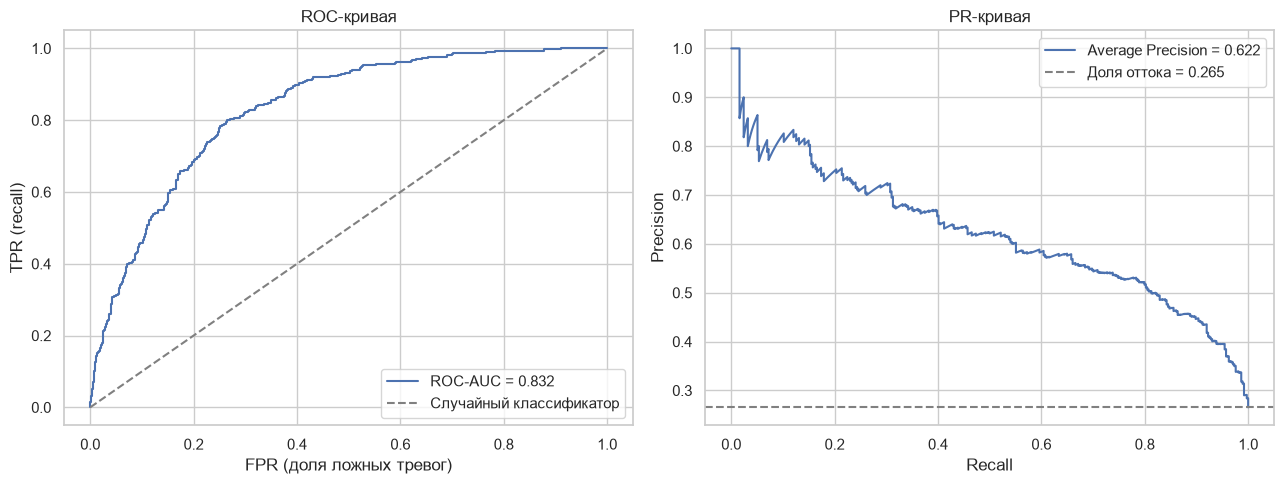

In [7]:
fpr, tpr, _ = roc_curve(y_test, p_test)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, p_test):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label="Случайный классификатор")
axes[0].set_xlabel("FPR (доля ложных тревог)")
axes[0].set_ylabel("TPR (recall)")
axes[0].set_title("ROC-кривая")
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f"Average Precision = {ap:.3f}")
axes[1].axhline(y_test.mean(), linestyle='--', color='gray',
                label=f"Доля оттока = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR-кривая")
axes[1].legend()

plt.tight_layout()
plt.show()


**Примечание.** Доля оттока в датасете 26% завышает precision относительно многих реальных сегментов: при меньшей доле уходящих precision при том же recall падает. Высокий ROC-AUC не переносится на другой сегмент автоматически — base rate нужно учитывать.

**Задача 3.**
Сравните precision, recall и F1 при пороге 0.5 с ожидаемым поведением при доле оттока 5% (вместо 26%): как изменится precision при том же recall? Объясните через формулу precision и через уровень PR-кривой. Ответ — в «Ваш ответ».

In [8]:
pred_05 = (p_test >= 0.5).astype(int)
cm_05 = confusion_matrix(y_test, pred_05)
tn, fp, fn, tp = cm_05.ravel()

tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
pi = 0.05

precision_26 = tp / (tp + fp)
precision_05 = (tpr * pi) / (tpr * pi + fpr * (1 - pi))

print(f"Recall при пороге 0.5: {tpr:.3f}")
print(f"FPR при пороге 0.5: {fpr:.3f}")
print(f"Precision при текущей доле positives: {precision_26:.3f}")
print(f"Ожидаемый precision при base rate 5%: {precision_05:.3f}")


Recall при пороге 0.5: 0.521
FPR при пороге 0.5: 0.117
Precision при текущей доле positives: 0.617
Ожидаемый precision при base rate 5%: 0.190


**Ваш ответ:**

При неизменных TPR и FPR переход от доли оттока около 26% к 5% снизит precision, потому что в знаменателе precision появляется гораздо больше отрицательных объектов относительно положительных:

$$
Precision=\frac{TPR\cdot\pi}{TPR\cdot\pi+FPR\cdot(1-\pi)}.
$$

Recall при том же пороге и неизменном распределении score по классам останется примерно тем же, а F1 снизится из-за падения precision. На PR-кривой это соответствует более низкому базовому уровню: случайный уровень становится 0.05 вместо примерно 0.26.


**Задача со звёздочкой.**
Докажите равенство $AUC = P\big(s(x^+) > s(x^-)\big)$. Подсказка: запишите AUC как интеграл по всем порогам $t$ и сверните его к ранговой статистике Манна–Уитни (доле пар «ушёл–остался», где ушедший получил больший скор).

**Ваше доказательство:**

Для порога $t$:

$$
TPR(t)=P(s(X^+)>t),
\qquad
FPR(t)=P(s(X^-)>t).
$$

Пусть $F_-(t)=P(s(X^-)\le t)$. Тогда

$$
AUC=\int TPR\,dF_-
=
\int P(s(X^+)>t)\,dF_-(t).
$$

По теореме Фубини:

$$
AUC=P(s(X^+)>s(X^-)).
$$

Эта вероятность совпадает с долей пар «положительный объект имеет больший score», то есть с нормированной статистикой Манна–Уитни. Поэтому

$$
\boxed{AUC=P(s(x^+)>s(x^-))}
$$


## 4. Порог: стоимость ошибок и пропускная способность

### Математический аппарат

Порог 0.5 — просто нейтральное значение, а не «правильное». Пусть ложная тревога стоит $c_{FP}$ (неоправданная скидка, лишний звонок), а пропуск оттока — $c_{FN}$ (потерянный клиент). Ожидаемая цена решения при пороге $t$:

$$C(t) = c_{FP} \cdot FP(t) + c_{FN} \cdot FN(t), \qquad t^* = \arg\min_{t} C(t)$$

Для откалиброванной модели есть ориентир: предлагать удержание выгодно, когда ожидаемая цена ложной тревоги ниже цены пропуска:

$$(1-p)\,c_{FP} < p\,c_{FN} \quad\Longleftrightarrow\quad p > \frac{c_{FP}}{c_{FP} + c_{FN}}$$

*Смысл:* чем дороже потерянный клиент относительно лишнего удержания, тем ниже порог. При $c_{FN} = 20\,c_{FP}$ получаем $t^* \approx 0.05$ — звонить стоит уже при 5% вероятности ухода.

**Ограничение по пропускной способности.** Даже оптимальный по цене порог может породить больше касаний, чем отдел удержания успевает обработать. Тогда порог выбирают как минимум стоимости при ограничении: число предложений на 10 000 клиентов не больше $K$.

Порог по стоимости: 0.06 (cost = 723, предложений/10k = 7189)
Теоретический ориентир: 0.048
С ограничением <= 500 предложений/10k: 0.72 (cost = 6492)


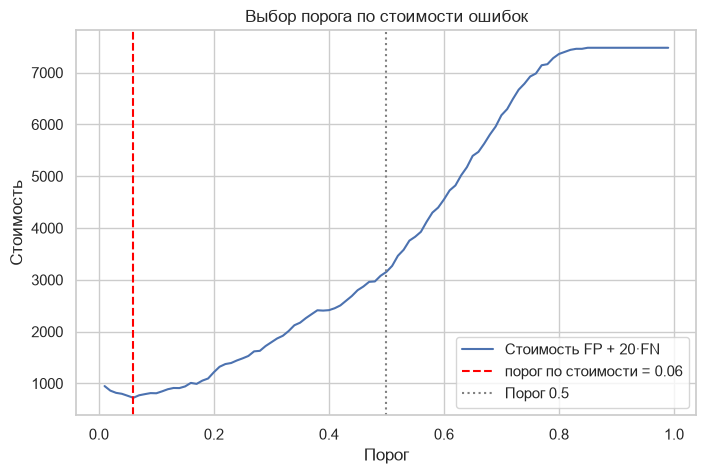

In [9]:
C_FP, C_FN = 1, 20

thresholds = np.linspace(0.01, 0.99, 99)
rows = []

for t in thresholds:
    tn, fp, fn, tp = confusion_matrix(y_val, p_val >= t).ravel()
    rows.append((t, fp + C_FN * fn, (p_val >= t).mean() * 10000))

th_table = pd.DataFrame(rows, columns=['threshold', 'cost', 'offers_per_10k'])

best = th_table.loc[th_table['cost'].idxmin()]
cap = th_table[th_table['offers_per_10k'] <= 500]

print(f"Порог по стоимости: {best['threshold']:.2f} (cost = {best['cost']:.0f}, предложений/10k = {best['offers_per_10k']:.0f})")
print(f"Теоретический ориентир: {C_FP / (C_FP + C_FN):.3f}")

if len(cap):
    best_cap = cap.loc[cap['cost'].idxmin()]
    print(f"С ограничением <= 500 предложений/10k: {best_cap['threshold']:.2f} (cost = {best_cap['cost']:.0f})")
else:
    best_cap = None
    print("Ограничение <= 500 предложений/10k недостижимо на заданной сетке.")

plt.figure(figsize=(8, 5))
plt.plot(th_table['threshold'], th_table['cost'], label='Стоимость FP + 20·FN')
plt.axvline(best['threshold'], linestyle='--', color='red', label=f"порог по стоимости = {best['threshold']:.2f}")
plt.axvline(0.5, linestyle=':', color='gray', label='Порог 0.5')
plt.xlabel('Порог')
plt.ylabel('Стоимость')
plt.title('Выбор порога по стоимости ошибок')
plt.legend()
plt.show()

T_STAR = float(best['threshold'])


In [10]:
pred_star = (p_test >= T_STAR).astype(int)
cm_star = confusion_matrix(y_test, pred_star)

result = {
    'threshold': round(float(T_STAR), 2),
    'accuracy': accuracy_score(y_test, pred_star),
    'precision': precision_score(y_test, pred_star, zero_division=0),
    'recall': recall_score(y_test, pred_star, zero_division=0),
    'f1': f1_score(y_test, pred_star, zero_division=0),
    'roc_auc': roc_auc_score(y_test, p_test),
    'average_precision': average_precision_score(y_test, p_test),
    'log_loss': log_loss(y_test, p_test),
}

print("Confusion matrix (порог из validation):")
print(cm_star)

for k, v in result.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

print(f"Предложений на 10 000 клиентов: {pred_star.mean() * 10000:.0f}")

run = wandb.init(
        project="apml-course",
        name="logreg-churn-baseline",
        config={
            "model": "LogisticRegression",
            "C": 0.3,
            "split": "60/20/20",
            "cost_ratio_FN_FP": C_FN,
            "threshold": float(T_STAR)
        }
    )
wandb.log(result)
run.finish()


Confusion matrix (порог из validation):
[[397 638]
 [ 14 360]]
threshold: 0.060
accuracy: 0.537
precision: 0.361
recall: 0.963
f1: 0.525
roc_auc: 0.832
average_precision: 0.622
log_loss: 0.431
Предложений на 10 000 клиентов: 7083


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


accuracy,▁
average_precision,▁
f1,▁
log_loss,▁
precision,▁
recall,▁
roc_auc,▁
threshold,▁
accuracy,0.53726
average_precision,0.62248
f1,0.52478


**Практическая применимость.** Низкий порог повышает recall почти до единицы, но создаёт много ложных тревог: дёргаем клиентов, которые и так остались бы. Качество модели и операционная пригодность — разные вещи: порог выбирают вместе с владельцем процесса удержания, зная стоимость ошибок и сменную пропускную способность.

**Задача 4.**
Исследуйте отношения $c_{FN}/c_{FP} \in \{1, 5, 20, 100\}$: для каждого подберите порог на validation, затем посчитайте на test recall, precision, FP, FN и стоимость. Добавьте ограничение по нагрузке и сравните пороги. Сформулируйте рекомендацию для двух сценариев: массовая рассылка со скидкой и персональный звонок менеджера. Ответ — в «Ваш ответ».

In [11]:
ratios = [1, 5, 20, 100]
rows = []

for ratio in ratios:
    costs = []
    for t in thresholds:
        tn, fp, fn, tp = confusion_matrix(y_val, p_val >= t).ravel()
        costs.append((t, fp + ratio * fn, (p_val >= t).mean() * 10000))
    tmp = pd.DataFrame(costs, columns=['threshold', 'cost', 'offers_per_10k'])
    best_r = tmp.loc[tmp['cost'].idxmin()]
    cap_r = tmp[tmp['offers_per_10k'] <= 500]
    best_cap_r = cap_r.loc[cap_r['cost'].idxmin()] if len(cap_r) else None
    t_r = best_r['threshold']
    pred_r = (p_test >= t_r).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_r).ravel()
    rows.append({
        'ratio_FN_FP': ratio,
        'threshold': t_r,
        'precision': precision_score(y_test, pred_r, zero_division=0),
        'recall': recall_score(y_test, pred_r, zero_division=0),
        'f1': f1_score(y_test, pred_r, zero_division=0),
        'FP': fp,
        'FN': fn,
        'cost': fp + ratio * fn,
        'offers_per_10k': pred_r.mean() * 10000,
        'threshold_cap500': None if best_cap_r is None else best_cap_r['threshold']
    })

ratio_table = pd.DataFrame(rows)
display(ratio_table)

print("Теоретические пороги:", {r: round(1 / (1 + r), 3) for r in ratios})


,ratio_FN_FP,threshold,precision,recall,f1,FP,FN,cost,offers_per_10k,threshold_cap500
0,1,0.50,0.617089,0.521390,0.565217,121,179,300,2242.725337,0.72
1,5,0.19,0.454545,0.868984,0.596878,390,49,635,5074.520937,0.72
2,20,0.06,0.360721,0.962567,0.524781,638,14,918,7083.037615,0.72
3,100,0.02,0.307629,0.991979,0.469620,835,3,1135,8559.261888,0.72


Теоретические пороги: {1: 0.5, 5: 0.167, 20: 0.048, 100: 0.01}


**Ваш ответ:**

При росте отношения $c_{FN}/c_{FP}$ порог по стоимости должен снижаться, потому что пропуск оттока становится дороже ложной тревоги. Для массовой рассылки со скидкой разумно учитывать стоимость большого числа FP и жёстче контролировать ограничение по нагрузке, поэтому порог выбирается совместно с допустимым числом предложений. Для персонального звонка стоимость FN может быть существенно выше, поэтому допустим более низкий порог, но только пока менеджеры справляются с объёмом контактов. Таблица выше показывает одновременно порог, precision, recall, F1, FP, FN и стоимость для всех четырёх отношений.


## 5. Практикум

Как и на втором занятии, все задания выполняются на **датасете вашего проекта** (том же, что в занятии 2). Если целевая переменная непрерывная (регрессионная задача) — сформулируйте бинарную подзадачу, например «выше медианы / ниже медианы», и отметьте, насколько такая постановка искусственна для вашей предметной области.

Каждый запуск модели логируйте в W&B отдельным run. После каждого задания заполните ячейку **«Вывод»**.

### Задание 5.1. Постановка и проверка утечек

Продумайте leakage checklist для своего датасета: есть ли признаки, недоступные в момент предсказания, и признаки, вычисленные с использованием будущего. Сформулируйте: что является «позитивом» (класс 1); какова его доля; какая цена у FP и FN в вашей предметной области и что страшнее.

**Ваш ответ:**

Позитивом является клиент, который уйдёт, то есть `Churn = 1`. В доступном ноутбуке доля позитивного класса около 26%. В момент прогноза допустимы только признаки, известные до начала кампании удержания. `customerID` исключается из признаков, а признаки, отражающие итоговые платежи или события после ухода, рассматриваются как потенциальная утечка. Главная ошибка для процесса удержания — пропуск реального ухода, поэтому $c_{FN}$ обычно выше $c_{FP}$; при этом слишком много FP перегружает отдел и увеличивает стоимость кампании.


### Задание 5.2. Базовый классификатор

Обучите логистическую регрессию на своих данных (стратифицированный split, весь препроцессинг внутри `Pipeline`). Сравните с `DummyClassifier`. Посчитайте accuracy, precision, recall, F1, ROC-AUC, AP, log-loss и залогируйте запуск в W&B. В «Выводе»: какая метрика оказалась неожиданной и почему.

In [12]:
p_base = model.predict_proba(X_test)[:, 1]
pred_base = (p_base >= 0.5).astype(int)

dummy_pred = dummy.predict(X_test)

base_metrics = {
    'accuracy': accuracy_score(y_test, pred_base),
    'precision': precision_score(y_test, pred_base, zero_division=0),
    'recall': recall_score(y_test, pred_base, zero_division=0),
    'f1': f1_score(y_test, pred_base, zero_division=0),
    'roc_auc': roc_auc_score(y_test, p_base),
    'average_precision': average_precision_score(y_test, p_base),
    'log_loss': log_loss(y_test, p_base),
}

dummy_metrics = {
    'accuracy': accuracy_score(y_test, dummy_pred),
    'precision': precision_score(y_test, dummy_pred, zero_division=0),
    'recall': recall_score(y_test, dummy_pred, zero_division=0),
    'f1': f1_score(y_test, dummy_pred, zero_division=0),
}

print("LogisticRegression:")
for k, v in base_metrics.items():
    print(f"{k}: {v:.3f}")

print("\nDummyClassifier:")
for k, v in dummy_metrics.items():
    print(f"{k}: {v:.3f}")

run = wandb.init(
        project="apml-course",
        name="logreg-churn-practice-base",
        config={"model": "LogisticRegression", "C": 0.3, "threshold": 0.5}
    )
wandb.log(base_metrics)
run.finish()


LogisticRegression:
accuracy: 0.787
precision: 0.617
recall: 0.521
f1: 0.565
roc_auc: 0.832
average_precision: 0.622
log_loss: 0.431

DummyClassifier:
accuracy: 0.735
precision: 0.000
recall: 0.000
f1: 0.000


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


accuracy,▁
average_precision,▁
f1,▁
log_loss,▁
precision,▁
recall,▁
roc_auc,▁
accuracy,0.78708
average_precision,0.62248
f1,0.56522
log_loss,0.43119


**Вывод:**

Самой неожиданной может выглядеть accuracy: при дисбалансе классов она остаётся заметно выше случайного уровня даже у модели, которая плохо ловит редкий класс. Поэтому для задачи оттока важнее смотреть на recall, precision, F1 и AP, а ROC-AUC использовать как показатель качества ранжирования.


### Задание 5.3. Матрица ошибок

Выведите `confusion_matrix` своей модели и опишите, какие ошибки она делает чаще (FP или FN) и насколько это плохо для вашей задачи из 5.1.

In [13]:
cm_base = confusion_matrix(y_test, pred_base)
tn, fp, fn, tp = cm_base.ravel()

print("Confusion matrix:")
print(cm_base)
print(f"FP: {fp}")
print(f"FN: {fn}")
print("Чаще:", "FP" if fp > fn else "FN" if fn > fp else "одинаково")


Confusion matrix:
[[914 121]
 [179 195]]
FP: 121
FN: 179
Чаще: FN


**Вывод:**

Матрица ошибок позволяет напрямую увидеть компромисс между ложными тревогами и пропусками. Для удержания клиентов FN обычно дороже FP, потому что FN означает пропущенного уходящего клиента, а FP — лишнее касание или скидку клиенту, который мог остаться и без неё.


### Задание 5.4. Порог: стоимость и пропускная способность

Задайте $c_{FP}$ и $c_{FN}$ из обоснования 5.1. Подберите порог **только на validation** (перебор из раздела 4) и оцените метрики на test. Добавьте ограничение по нагрузке: не более K предложений на 10 000 объектов, $K \in \{50, 100, 500\}$. Сравните пороги 0.5, по максимуму F1 и по минимуму стоимости.

In [14]:
grid = np.linspace(0.01, 0.99, 99)
rows = []

for t in grid:
    pred = (p_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    rows.append({
        'threshold': t,
        'cost': C_FP * fp + C_FN * fn,
        'f1': f1_score(y_val, pred, zero_division=0),
        'offers_per_10k': pred.mean() * 10000
    })

val_grid = pd.DataFrame(rows)

t_05 = 0.5
t_f1 = float(val_grid.loc[val_grid['f1'].idxmax(), 'threshold'])
t_cost = float(val_grid.loc[val_grid['cost'].idxmin(), 'threshold'])

cap_rows = []
for k in [50, 100, 500]:
    cap = val_grid[val_grid['offers_per_10k'] <= k]
    cap_rows.append({
        'K': k,
        'threshold': None if cap.empty else float(cap.loc[cap['cost'].idxmin(), 'threshold'])
    })

selected = pd.DataFrame([
    ['0.5', t_05],
    ['max F1', t_f1],
    ['min cost', t_cost]
], columns=['rule', 'threshold'])

test_rows = []
for _, row in selected.iterrows():
    t = float(row['threshold'])
    pred = (p_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    test_rows.append({
        'rule': row['rule'],
        'threshold': t,
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'FP': fp,
        'FN': fn,
        'cost': C_FP * fp + C_FN * fn,
        'offers_per_10k': pred.mean() * 10000
    })

test_thresholds = pd.DataFrame(test_rows)
print("Пороги на validation:")
display(selected)

print("Ограничения по нагрузке:")
display(pd.DataFrame(cap_rows))

print("Финальная оценка на test:")
display(test_thresholds)


Пороги на validation:


,rule,threshold
0,0.5,0.50
1,max F1,0.48
2,min cost,0.06


Ограничения по нагрузке:


,K,threshold
0,50,0.80
1,100,0.79
2,500,0.72


Финальная оценка на test:


,rule,threshold,precision,recall,f1,FP,FN,cost,offers_per_10k
0,0.5,0.50,0.617089,0.521390,0.565217,121,179,3701,2242.725337
1,max F1,0.48,0.597101,0.550802,0.573018,139,168,3499,2448.545067
2,min cost,0.06,0.360721,0.962567,0.524781,638,14,918,7083.037615


**Вывод:**

Порог 0.5 задаёт нейтральный компромисс, максимум F1 выбирает баланс precision и recall, а минимум стоимости учитывает бизнес-цену FP и FN. Ограничения $K=50,100,500$ дополнительно уменьшают число предложений и могут потребовать более высокого порога. Для финального бейзлайна порог фиксируется по validation, после чего выбранное правило один раз оценивается на test.


### Задание 5.5. Взвешивание классов

Обучите вторую модель — ту же логистическую регрессию с `class_weight='balanced'`. Сравните precision/recall/F1 с базовой, залогируйте запуск в W&B и сравните два run в интерфейсе. В «Выводе»: помогло ли взвешивание именно по вашей главной метрике из 5.1 и как оно повлияло на вероятности модели.

In [15]:
balanced_model = Pipeline([
    ('prep', preproc),
    ('clf', LogisticRegression(
        C=0.3,
        max_iter=1500,
        solver='liblinear',
        class_weight='balanced'
    )),
])

balanced_model.fit(X_train, y_train)

p_bal = balanced_model.predict_proba(X_test)[:, 1]
pred_bal = (p_bal >= 0.5).astype(int)

balanced_metrics = {
    'accuracy': accuracy_score(y_test, pred_bal),
    'precision': precision_score(y_test, pred_bal, zero_division=0),
    'recall': recall_score(y_test, pred_bal, zero_division=0),
    'f1': f1_score(y_test, pred_bal, zero_division=0),
    'roc_auc': roc_auc_score(y_test, p_bal),
    'average_precision': average_precision_score(y_test, p_bal),
    'log_loss': log_loss(y_test, p_bal),
    'mean_predicted_prob': p_bal.mean()
}

comparison = pd.DataFrame([base_metrics, balanced_metrics], index=['base', 'balanced'])
display(comparison)

run = wandb.init(
        project="apml-course",
        name="logreg-churn-practice-balanced",
        config={
            "model": "LogisticRegression",
            "C": 0.3,
            "class_weight": "balanced",
            "threshold": 0.5
        }
    )
wandb.log(balanced_metrics)
run.finish()


,accuracy,precision,recall,f1,roc_auc,average_precision,log_loss,mean_predicted_prob
base,0.787083,0.617089,0.521390,0.565217,0.831982,0.622477,0.431191,NaN
balanced,0.743080,0.510135,0.807487,0.625259,0.831623,0.622918,0.510354,0.419845


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


accuracy,▁
average_precision,▁
f1,▁
log_loss,▁
mean_predicted_prob,▁
precision,▁
recall,▁
roc_auc,▁
accuracy,0.74308
average_precision,0.62292
f1,0.62526


**Вывод:**

Взвешивание классов обычно увеличивает recall редкого класса и одновременно может снизить precision. Вероятности при этом сдвигаются вверх, поэтому их нельзя автоматически считать хорошо откалиброванными. Для сравнения моделей важна не только точность классификации, но и главная бизнес-метрика из постановки задачи.


### Задание 5.6. Итоговое резюме

В 5–7 предложениях: какая метрика будет главной в вашем проекте и почему; как повели себя ROC-AUC и AP на ваших данных; какой порог и какую модель вы зафиксируете как классификационный бейзлайн; какие ограничения (base rate, leakage, drift) нужно указать в отчёте.

**Резюме:**

Для прогноза оттока главной метрикой будет recall, потому что пропуск реально уходящего клиента дороже лишнего контакта. ROC-AUC показывает качество ранжирования по всей шкале порогов, а AP лучше отражает качество при дисбалансе классов и зависимости от base rate. В качестве классификационного бейзлайна фиксируется логистическая регрессия с препроцессингом внутри Pipeline. Порог выбирается на validation по заданной функции стоимости и ограничению на число контактов, а test используется только для финальной оценки. Взвешивание классов может повысить recall, но меняет вероятности и обычно требует отдельной работы с калибровкой. В отчёте нужно отдельно указать риск leakage, зависимость precision от доли оттока и возможный drift распределения клиентов во времени.


---

## P.S. Калибровка вероятностей

**Калибровка** — согласие между предсказанной вероятностью и реальной частотой: среди клиентов с $\hat{y} \approx 0.8$ уходит примерно 80%. Логистическая регрессия обычно откалибрована неплохо, а бустинг и нейросети — часто нет.

Проверяется **калибровочной кривой** (reliability diagram): объекты разбиваются на бины по $\hat{y}$, и средняя предсказанная вероятность сравнивается с эмпирической долей позитивов. Идеал — диагональ. Исправляют постфактум через **Platt scaling** или **изотоническую регрессию** (`CalibratedClassifierCV`).

**Когда это важно.** Когда сама вероятность — продукт: кредитный скоринг, медицина, оценка ожидаемой выручки от кампании удержания. Именно для откалиброванной модели справедлива формула порога $t^* = c_{FP}/(c_{FP}+c_{FN})$ из раздела 4. Если нужен только ранжинг или класс по порогу, достаточно ROC-AUC и AP.

**Замечание про `class_weight`.** Взвешивание классов меняет обучение и почти всегда портит калибровку: модель начинает систематически завышать вероятности редкого класса. Поэтому взвешивание и сдвиг порога не стоит применять одновременно — это двойной учёт дисбаланса.

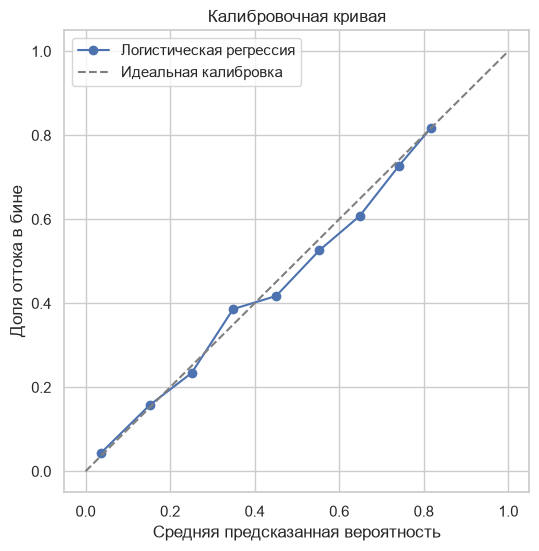

In [16]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Логистическая регрессия')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля оттока в бине")
plt.title("Калибровочная кривая")
plt.legend()
plt.show()


### Справочные материалы

- Telco Customer Churn (IBM): https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
- Документация scikit-learn (LogisticRegression): https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Метрики классификации в scikit-learn: https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics
- Документация Pandas: https://pandas.pydata.org/docs/